## Step 0 - Problem Statement and Proposed Solution

Pemantauan kualitas air permukaan secara kontinu saat ini sangat bergantung pada jaringan sensor Internet of Things (IoT). Meskipun mampu menghasilkan data dalam volume besar dengan resolusi waktu yang tinggi, sistem sensor IoT di lingkungan akuatik sangat rentan terhadap kegagalan teknis, seperti biofouling (penumpukan lumut/bakteri pada probe sensor), kehabisan daya, atau kerusakan kalibrasi, yang menghasilkan pembacaan data yang tidak valid. Di sisi lain, perubahan ekstrem pada kualitas air juga dapat disebabkan oleh kejadian nyata, seperti pembuangan limbah ilegal atau badai hujan yang menyebabkan lonjakan kekeruhan (turbidity) secara drastis. Tantangan komputasional utama dalam ranah ini adalah membedakan antara "fluktuasi ekstrem alami" dan "anomali sesungguhnya" (baik akibat kerusakan sensor maupun pencemaran) di tengah triliunan titik data yang tidak memiliki label (unlabeled data).

Metode deteksi ambang batas statis (static thresholding) tradisional terbukti tidak memadai karena parameter kualitas air bersifat sangat dinamis, multivariat, dan memiliki dependensi temporal (deret waktu). Misalnya, suhu 20°C mungkin **normal di musim panas**, tetapi sangat **abnormal di musim dingin** — meskipun secara global kedua nilai tersebut berada dalam rentang "normal". Anomali semacam ini disebut **anomali kontekstual** (contextual anomaly) dan membutuhkan rekayasa fitur (feature engineering) yang mampu mengekstrak konteks historis, sehingga algoritma dapat memahami pola siklus alami sungai sebelum mencoba mencari keanehan di dalamnya.

Untuk mengatasi ketiadaan label anomali pada data historis, pendekatan Unsupervised Machine Learning seperti Local Outlier Factor (LOF), One-Class Support Vector Machine (OCSVM), dan Isolation Forest (iForest) menjadi solusi yang paling optimal. Namun, evaluasi kinerja model unsupervised seringkali bersifat subjektif. Oleh karena itu, simulasi injeksi anomali sintetik (synthetic anomaly injection) yang merepresentasikan **dua jenis anomali yang berbeda** — (1) anomali global/ekstrem seperti kerusakan sensor dan pencemaran berat, serta (2) anomali kontekstual yang hanya terlihat abnormal relatif terhadap musim/baseline — mutlak diperlukan sebagai ground truth objektif untuk mengukur metrik F1-Score model pada saat pengujian.

Lebih lanjut, setiap algoritma unsupervised memiliki kelemahan bawaan (blind spots); algoritma berbasis kepadatan lokal (LOF) mungkin unggul dalam mendeteksi penyimpangan kontekstual, sementara algoritma berbasis batas (OCSVM) dan berbasis isolasi pohon (iForest) memiliki bias induktif yang berbeda. Untuk menekan tingginya angka False Positive yang sering menjangkiti sistem deteksi anomali tunggal, penerapan **Heterogeneous Ensemble berbasis Voting** (OR, Majority, AND) diusulkan sebagai strategi penggabungan keputusan. Pada akhirnya, kontribusi dari seluruh rekayasa komputasional ini divalidasi melalui studi ablasi (ablation study) untuk membuktikan secara empiris **fitur mana yang benar-benar berkontribusi positif** terhadap peningkatan performa model.

## Step 1 - Import Library

Seluruh library yang dibutuhkan diimpor di satu tempat agar mudah ditelusuri:
- **pandas, numpy**: manipulasi data tabular dan numerik.
- **matplotlib, seaborn, plotly**: visualisasi statis dan interaktif.
- **scikit-learn**: algoritma `LocalOutlierFactor`, `OneClassSVM`, `IsolationForest`, `RobustScaler`, dan metrik evaluasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    f1_score,
    classification_report,
    accuracy_score,
    confusion_matrix,
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 2 - Data Loading and Initial Inspection

Dataset Clackamas River dimuat. Hanya kolom parameter kualitas air yang relevan yang dipilih, lalu diberi nama yang lebih mudah dibaca. Kolom waktu dikonversi menjadi index dan data difilter ke periode 10 tahun (2014–2023).

In [2]:
df_raw = pd.read_csv("../data/clackamas_river.csv")
print(f"Ukuran data mentah: {df_raw.shape}")

Ukuran data mentah: (6209, 34)


In [3]:
rename_dict = {
    "00010_Mean":   "Temperature",
    "00300_Mean":   "Dissolved Oxygen",
    "00400_Median": "pH",
    "63680_Median": "Turbidity",
}

selected_columns = ['datetime'] + list(rename_dict.keys())
df = df_raw[selected_columns].copy()
df = df.rename(columns=rename_dict)
df.head()

,datetime,Temperature,Dissolved Oxygen,pH,Turbidity
0,2007-01-01 00:00:00+00:00,4.2,13.7,7.4,3.9
1,2007-01-02 00:00:00+00:00,5.3,13.3,7.4,3.7
2,2007-01-03 00:00:00+00:00,6.4,13.1,7.3,78.5
3,2007-01-04 00:00:00+00:00,6.2,13.2,7.2,61.0
4,2007-01-05 00:00:00+00:00,5.5,13.4,7.3,23.0


In [4]:
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')

baris_rusak = df['datetime'].isna().sum()
print(f"Jumlah baris dengan datetime rusak yang akan dibuang: {baris_rusak} baris")

df = df.dropna(subset=['datetime']).set_index('datetime')

Jumlah baris dengan datetime rusak yang akan dibuang: 217 baris


In [5]:
df = df.loc['2014':'2023']
print("--- Info Data Setelah Filter 10 Tahun ---")
df.info()

--- Info Data Setelah Filter 10 Tahun ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3562 entries, 2014-01-01 00:00:00+00:00 to 2023-12-31 00:00:00+00:00
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature       3560 non-null   float64
 1   Dissolved Oxygen  3541 non-null   float64
 2   pH                3522 non-null   float64
 3   Turbidity         3512 non-null   float64
dtypes: float64(4)
memory usage: 139.1 KB


## Step 3 - Exploratory Data Analysis (EDA)

EDA bertujuan memahami karakteristik data sebelum pemodelan: statistik deskriptif, identifikasi gap waktu, distribusi tiap parameter, tren temporal, dan korelasi antar parameter.

In [6]:
print("--- Statistik Deskriptif ---")
df.describe()

--- Statistik Deskriptif ---


,Temperature,Dissolved Oxygen,pH,Turbidity
count,3560.000000,3541.000000,3522.000000,3512.000000
mean,11.504775,11.134425,7.526917,2.579584
std,5.604703,1.414884,0.269678,4.771787
min,0.900000,8.200000,6.800000,0.100000
25%,6.700000,9.900000,7.300000,0.800000
50%,10.100000,11.400000,7.500000,1.400000
75%,16.200000,12.300000,7.700000,2.500000
max,23.900000,14.500000,8.400000,91.600000


### Step 3.A - Identifikasi Hari yang Hilang

Karena data bersifat deret waktu harian, perlu dipastikan apakah ada hari yang tidak memiliki record. Hari yang hilang akan dimasukkan kembali sebagai baris kosong (`NaN`) melalui `reindex` agar tahap imputasi berikutnya bisa menanganinya.

In [7]:
full_date_range = pd.date_range(start='2014-01-01', end='2023-12-31', freq='D', tz='UTC')
missing_dates = full_date_range.difference(df.index)

print(f"Total hari yang hilang dari sensor: {len(missing_dates)} hari")
if len(missing_dates) > 0:
    print("Contoh 5 tanggal yang hilang:", [d.strftime('%Y-%m-%d') for d in missing_dates[:5]])

df = df.reindex(full_date_range)
df.index.name = 'datetime'
print(f"Total baris setelah reindex: {len(df)} baris")

Total hari yang hilang dari sensor: 90 hari
Contoh 5 tanggal yang hilang: ['2014-10-05', '2014-10-06', '2014-11-21', '2014-11-22', '2014-11-23']
Total baris setelah reindex: 3652 baris


In [8]:
print("--- Total Nilai Kosong (NaN) per Fitur ---")
print(df.isna().sum())

--- Total Nilai Kosong (NaN) per Fitur ---
Temperature          92
Dissolved Oxygen    111
pH                  130
Turbidity           140
dtype: int64


### Step 3.B - Visualisasi Tren Temporal

Plot deret waktu untuk setiap parameter. Area berwarna merah menandakan periode dimana sensor tidak menghasilkan data (gap).

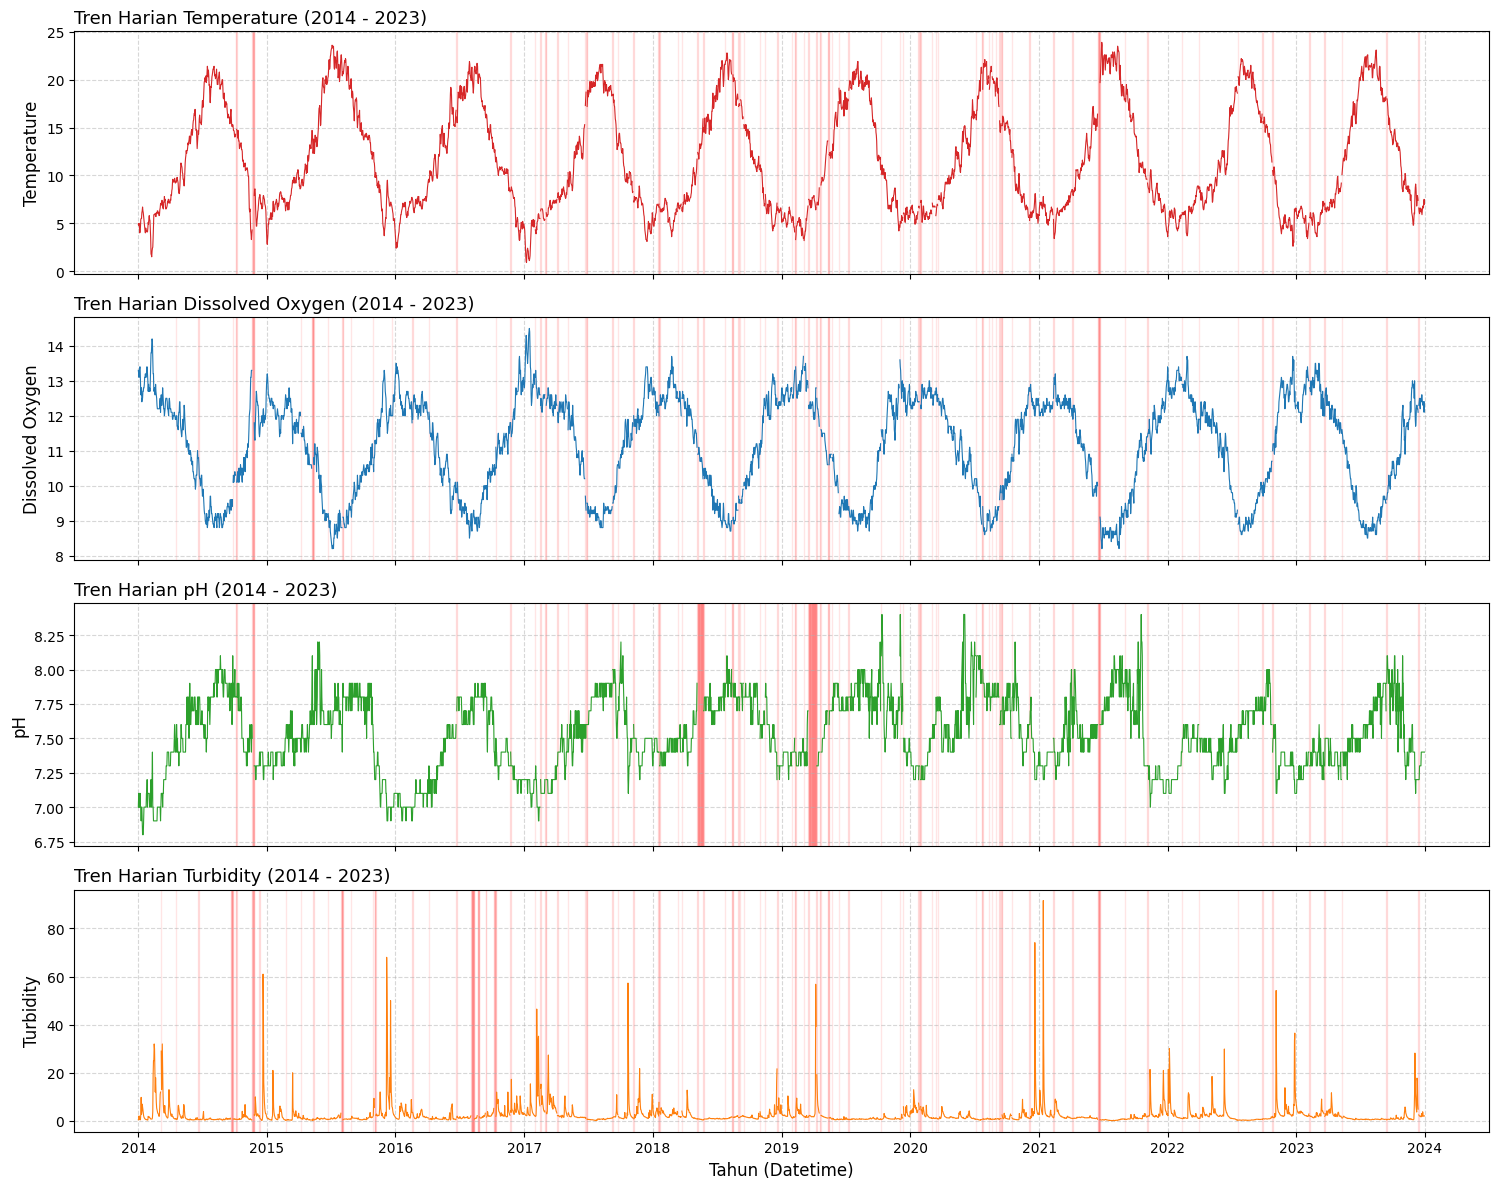

In [9]:
features = ['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity']
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 12), sharex=True)

for i, col in enumerate(features):
    axes[i].plot(df.index, df[col], color=colors[i], linewidth=0.8)
    axes[i].set_ylabel(col, fontsize=12)
    axes[i].set_title(f"Tren Harian {col} (2014 - 2023)", fontsize=13, loc='left')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    missing_mask = df[col].isna()
    for j in range(len(missing_mask) - 1):
        if missing_mask.iloc[j]:
            axes[i].axvspan(df.index[j], df.index[j+1], color='red', alpha=0.1)

plt.xlabel("Tahun (Datetime)", fontsize=12)
plt.tight_layout()
plt.show()

### Step 3.C - Distribusi Tiap Parameter

Histogram + boxplot untuk melihat skewness, ekor distribusi, dan keberadaan outlier alami.

In [10]:
def plot_distribution(df, column, color):
    fig = px.histogram(
        df, x=column, marginal="box",
        title=f"Distribusi dan Boxplot Historis: {column}",
        color_discrete_sequence=[color],
        opacity=0.8, nbins=50,
    )
    fig.update_layout(
        xaxis_title=f"Nilai {column}",
        yaxis_title="Frekuensi (Jumlah Hari)",
        bargap=0.05, plot_bgcolor='white',
    )
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
    fig.show()

plot_distribution(df, 'Temperature',      '#EF553B')
plot_distribution(df, 'Dissolved Oxygen', '#00CC96')
plot_distribution(df, 'pH',               '#AB63FA')
plot_distribution(df, 'Turbidity',        '#FFA15A')

### Step 3.D - Matriks Korelasi

Korelasi antar parameter penting untuk memahami apakah ada hubungan yang kuat. Misalnya, Temperature dan Dissolved Oxygen biasanya berkorelasi negatif (semakin hangat, semakin rendah DO).

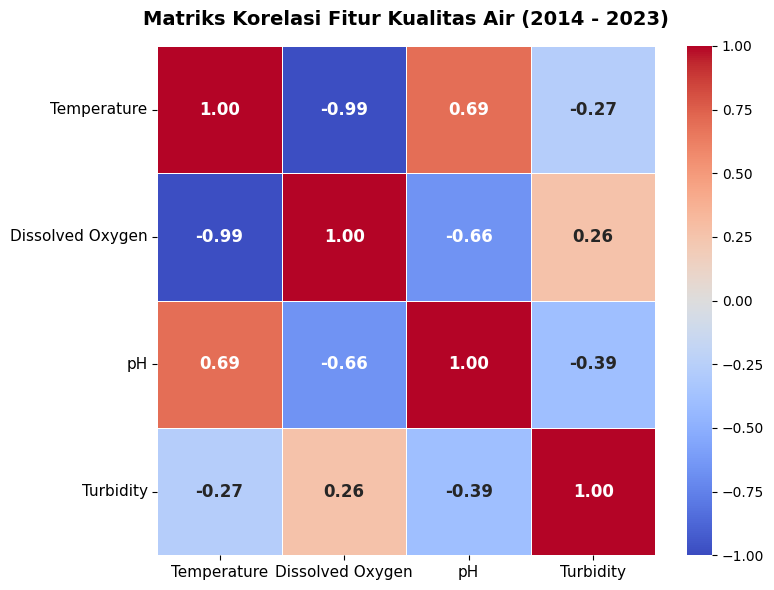

In [11]:
corr_matrix = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
    linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={"size": 12, "weight": "bold"}
)
plt.title("Matriks Korelasi Fitur Kualitas Air (2014 - 2023)", fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

## Step 4 - Data Cleaning and Imputation

Imputasi dilakukan dengan kombinasi `bfill` lalu `ffill`. Strategi ini dipilih karena:
- Data bersifat deret waktu yang berkorelasi temporal.
- Nilai sensor kualitas air cenderung berubah perlahan dari hari ke hari.
- Sederhana, deterministik, dan tidak memerlukan model tambahan.

In [12]:
print("--- Missing Values SEBELUM Imputasi ---")
print(df.isna().sum())

--- Missing Values SEBELUM Imputasi ---
Temperature          92
Dissolved Oxygen    111
pH                  130
Turbidity           140
dtype: int64


In [13]:
df = df.bfill().ffill()
print("--- Missing Values SESUDAH Imputasi ---")
print(df.isna().sum())

--- Missing Values SESUDAH Imputasi ---
Temperature         0
Dissolved Oxygen    0
pH                  0
Turbidity           0
dtype: int64


## Step 5 - Data Splitting (Time-Based)

Karena data deret waktu, splitting **harus mengikuti urutan waktu** untuk menghindari data leakage dari masa depan ke masa lalu.

| Subset      | Periode     | Tujuan                                      |
|-------------|-------------|---------------------------------------------|
| Training    | 2014–2020   | Melatih model (diasumsikan mayoritas normal) |
| Validation  | 2021        | Hyperparameter tuning                       |
| Test        | 2022–2023   | Evaluasi akhir + ensemble + ablation        |

In [14]:
train_raw = df.loc['2014':'2020'].copy()
val_raw   = df.loc['2021'].copy()
test_raw  = df.loc['2022':'2023'].copy()

# Training diasumsikan mayoritas normal
train_raw['Label'] = 0

print(f"Train : {train_raw.shape[0]} hari ({train_raw.index.min().date()} -> {train_raw.index.max().date()})")
print(f"Val   : {val_raw.shape[0]} hari ({val_raw.index.min().date()} -> {val_raw.index.max().date()})")
print(f"Test  : {test_raw.shape[0]} hari ({test_raw.index.min().date()} -> {test_raw.index.max().date()})")

Train : 2557 hari (2014-01-01 -> 2020-12-31)
Val   : 365 hari (2021-01-01 -> 2021-12-31)
Test  : 730 hari (2022-01-01 -> 2023-12-31)


## Step 6 - Synthetic Anomaly Injection

Karena dataset tidak memiliki label anomali, ground truth dibuat secara sintetik. Untuk membuat benchmark yang **realistis**, kita menginjeksikan **dua jenis anomali** dengan proporsi yang seimbang (50:50):

### (a) Anomali Global / Ekstrem

Nilai yang sangat menyimpang dari keseluruhan distribusi, mudah dikenali tanpa konteks temporal.

- **Univariat (Sensor Failure)**: `Turbidity` diset ke 3× kuantil-99 (lonjakan ekstrem). Mensimulasikan biofouling atau probe rusak.
- **Multivariat (Pollution Event)**: `Temperature` naik +6°C **dan** `Dissolved Oxygen` turun −3 mg/L secara bersamaan. Mensimulasikan pencemaran termal.

### (b) Anomali Kontekstual

Nilai yang **masuk akal secara global**, tetapi **abnormal relatif terhadap musimnya**.

- **Univariat (Unusual Temperature for Season)**: `Temperature` diset ke `seasonal_mean + 3σ` dari bulan yang sama — nilainya masih dalam rentang historis tapi jauh menyimpang dari bulan itu.
- **Multivariat (Season Swap)**: `Temperature` dan `Dissolved Oxygen` diset ke **nilai rata-rata bulan berlawanan** (musim dingin di musim panas). Misalnya, pada Juli nilai diganti dengan nilai rata-rata Januari.

Injeksi dilakukan **pada data mentah** (sebelum feature engineering dan scaling) sehingga semua fitur turunan yang dihitung setelahnya akan otomatis merefleksikan anomali dengan cara yang konsisten dan realistis.

In [15]:
def inject_anomalies(df_raw_in, n_uni, n_multi, seed):
    rng = np.random.default_rng(seed)
    di = df_raw_in.copy()
    di['Label'] = 0

    idx = di.index.to_numpy()
    uni_dates = rng.choice(idx, size=n_uni, replace=False)
    half_uni = n_uni // 2

    # --- UNIVARIAT ---
    # (a) Global: lonjakan Turbidity ekstrem (sensor failure)
    spike_value = di['Turbidity'].quantile(0.99) * 3
    for date in uni_dates[:half_uni]:
        di.loc[date, 'Turbidity'] = spike_value
        di.loc[date, 'Label'] = 1          # GLOBAL

    # (b) Kontekstual: Temperature tinggi untuk musimnya
    for date in uni_dates[half_uni:]:
        month = pd.Timestamp(date).month
        same_month = di[di.index.month == month]['Temperature']
        di.loc[date, 'Temperature'] = same_month.mean() + 3.0 * same_month.std()
        di.loc[date, 'Label'] = 2          # KONTEKSTUAL  <-- berubah

    # --- MULTIVARIAT ---
    remaining = di.index[di['Label'] == 0].to_numpy()
    multi_dates = rng.choice(remaining, size=n_multi, replace=False)
    half_multi = n_multi // 2

    # (a) Global: Temperature +6, DO -3 (pencemaran termal)
    for date in multi_dates[:half_multi]:
        di.loc[date, 'Temperature']      += 6.0
        di.loc[date, 'Dissolved Oxygen'] -= 3.0
        di.loc[date, 'Label'] = 1          # GLOBAL

    # (b) Kontekstual: swap ke bulan berlawanan
    for date in multi_dates[half_multi:]:
        month = pd.Timestamp(date).month
        opposite_month = ((month + 5) % 12) + 1
        opp = di[di.index.month == opposite_month]
        di.loc[date, 'Temperature']      = opp['Temperature'].mean()
        di.loc[date, 'Dissolved Oxygen'] = opp['Dissolved Oxygen'].mean()
        di.loc[date, 'Label'] = 2          # KONTEKSTUAL  <-- berubah

    return di

val_inj  = inject_anomalies(val_raw,  n_uni=36, n_multi=36, seed=42)
test_inj = inject_anomalies(test_raw, n_uni=72, n_multi=72, seed=143)

print("--- Laporan Ground Truth Buatan ---")
print(f"Validation: {(val_inj['Label']==0).sum()} normal, "
      f"{(val_inj['Label']==1).sum()} global, "           # <-- berubah
      f"{(val_inj['Label']==2).sum()} kontekstual")        # <-- berubah
print(f"Test      : {(test_inj['Label']==0).sum()} normal, "
      f"{(test_inj['Label']==1).sum()} global, "           # <-- berubah
      f"{(test_inj['Label']==2).sum()} kontekstual")        # <-- berubah

--- Laporan Ground Truth Buatan ---
Validation: 293 normal, 36 global, 36 kontekstual
Test      : 586 normal, 72 global, 72 kontekstual


### Step 6.A - Visualisasi Lokasi Anomali Sintetik

Plot ini memvisualisasikan letak anomali sintetik pada deret waktu test set. Perhatikan bahwa banyak anomali (terutama yang kontekstual) **tidak terlihat mencolok** pada plot — nilainya masih berada di rentang normal secara global, tetapi abnormal untuk musimnya.

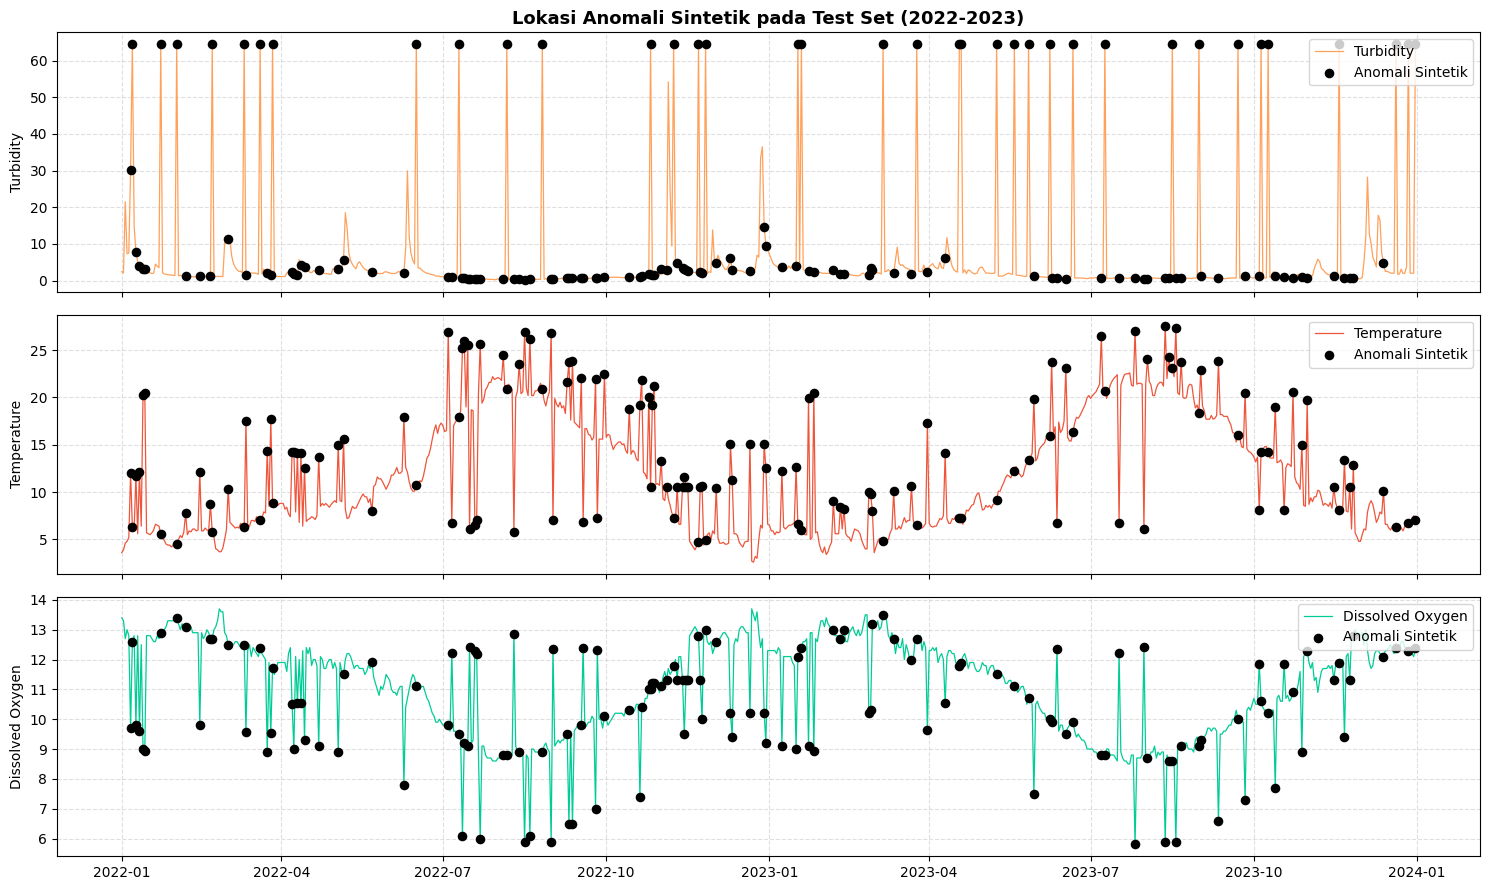

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
plot_cols = ['Turbidity', 'Temperature', 'Dissolved Oxygen']
plot_colors = ['#FFA15A', '#EF553B', '#00CC96']
anomaly_mask = test_inj['Label'] >= 1

for ax, col, c in zip(axes, plot_cols, plot_colors):
    ax.plot(test_inj.index, test_inj[col], color=c, linewidth=0.9, label=col)
    ax.scatter(test_inj.index[anomaly_mask], test_inj[col][anomaly_mask],
               color='black', s=35, zorder=5, label='Anomali Sintetik')
    ax.set_ylabel(col)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right')

axes[0].set_title("Lokasi Anomali Sintetik pada Test Set (2022-2023)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7 - Feature Engineering: Investigasi Dua Pendekatan

Pada tahap ini, tujuan utamanya adalah memperkaya data mentah dengan **konteks temporal** sehingga model dapat membedakan nilai yang "normal untuk musim ini" dari nilai yang "aneh untuk musim ini". Kami menginvestigasi **dua kandidat pendekatan feature engineering**, lalu membandingkannya secara empiris pada ablation study (Step 12).

### Kandidat A — Rolling Statistics (7 hari)

Intuisi awal: hitung rata-rata dan standar deviasi bergerak 7 hari (`Mean_7D`, `Std_7D`) dan first-order difference (`Diff`) untuk menangkap tren jangka pendek dan perubahan antar hari.

$$\text{Mean}_{7D}(x_t) = \frac{1}{7}\sum_{i=t-6}^{t} x_i \qquad \text{Diff}(x_t) = x_t - x_{t-1}$$

### Kandidat B — Causal Z-Score (30 hari)

Intuisi alternatif: hitung z-score terhadap **baseline 30 hari sebelumnya**, tanpa menyertakan hari-X itu sendiri (sifat *causal*).

$$\text{ZScore}(x_t) = \frac{x_t - \mu_{[t-30,\, t-1]}}{\sigma_{[t-30,\, t-1]}}$$

### Selain itu, kedua kandidat sama-sama dilengkapi:

- **Cyclical encoding bulan** (`Month_Sin`, `Month_Cos`) → menjaga sifat siklik bulan (Desember dekat dengan Januari).

Pada Step 12 nanti, ketiga skenario (**Raw Only**, **Raw + Rolling (Kandidat A)**, **Raw + ZScore (Kandidat B)**) akan dibandingkan head-to-head untuk menentukan mana yang benar-benar meningkatkan F1-Score.

In [17]:
def add_features(df_in, base_features):
    d = df_in.copy()

    # Cyclical encoding bulan (umum untuk kedua kandidat)
    d['Month_Sin'] = np.sin(2 * np.pi * d.index.month / 12)
    d['Month_Cos'] = np.cos(2 * np.pi * d.index.month / 12)

    # Kandidat A: Rolling statistics 7 hari + first-order difference
    for col in base_features:
        d[f'{col}_Diff']    = d[col].diff()
        d[f'{col}_Mean_7D'] = d[col].rolling(window=7, min_periods=1).mean()
        d[f'{col}_Std_7D']  = d[col].rolling(window=7, min_periods=2).std()

    # Kandidat B: Causal Z-Score 30 hari (baseline tidak termasuk hari-X)
    for col in base_features:
        rolling_mean = d[col].shift(1).rolling(window=30, min_periods=5).mean()
        rolling_std  = d[col].shift(1).rolling(window=30, min_periods=5).std()
        d[f'{col}_ZScore'] = (d[col] - rolling_mean) / (rolling_std + 1e-6)

    return d.bfill()

train_feat = add_features(train_raw, features)
val_feat   = add_features(val_inj,   features)
test_feat  = add_features(test_inj,  features)

print("--- Jumlah kolom setelah feature engineering ---")
print(f"Total kolom: {train_feat.shape[1]}")
print()
print("--- Contoh kolom yang tersedia ---")
print(list(train_feat.columns))

--- Jumlah kolom setelah feature engineering ---
Total kolom: 23

--- Contoh kolom yang tersedia ---
['Temperature', 'Dissolved Oxygen', 'pH', 'Turbidity', 'Label', 'Month_Sin', 'Month_Cos', 'Temperature_Diff', 'Temperature_Mean_7D', 'Temperature_Std_7D', 'Dissolved Oxygen_Diff', 'Dissolved Oxygen_Mean_7D', 'Dissolved Oxygen_Std_7D', 'pH_Diff', 'pH_Mean_7D', 'pH_Std_7D', 'Turbidity_Diff', 'Turbidity_Mean_7D', 'Turbidity_Std_7D', 'Temperature_ZScore', 'Dissolved Oxygen_ZScore', 'pH_ZScore', 'Turbidity_ZScore']


### Step 7.A - Visualisasi Perbedaan Kedua Kandidat Fitur

Visualisasi ini sangat penting untuk memahami **mengapa** nantinya salah satu kandidat akan menang di ablation study. Kita fokus pada Temperature di test set, karena banyak anomali kontekstual yang diinjeksikan pada kolom tersebut.

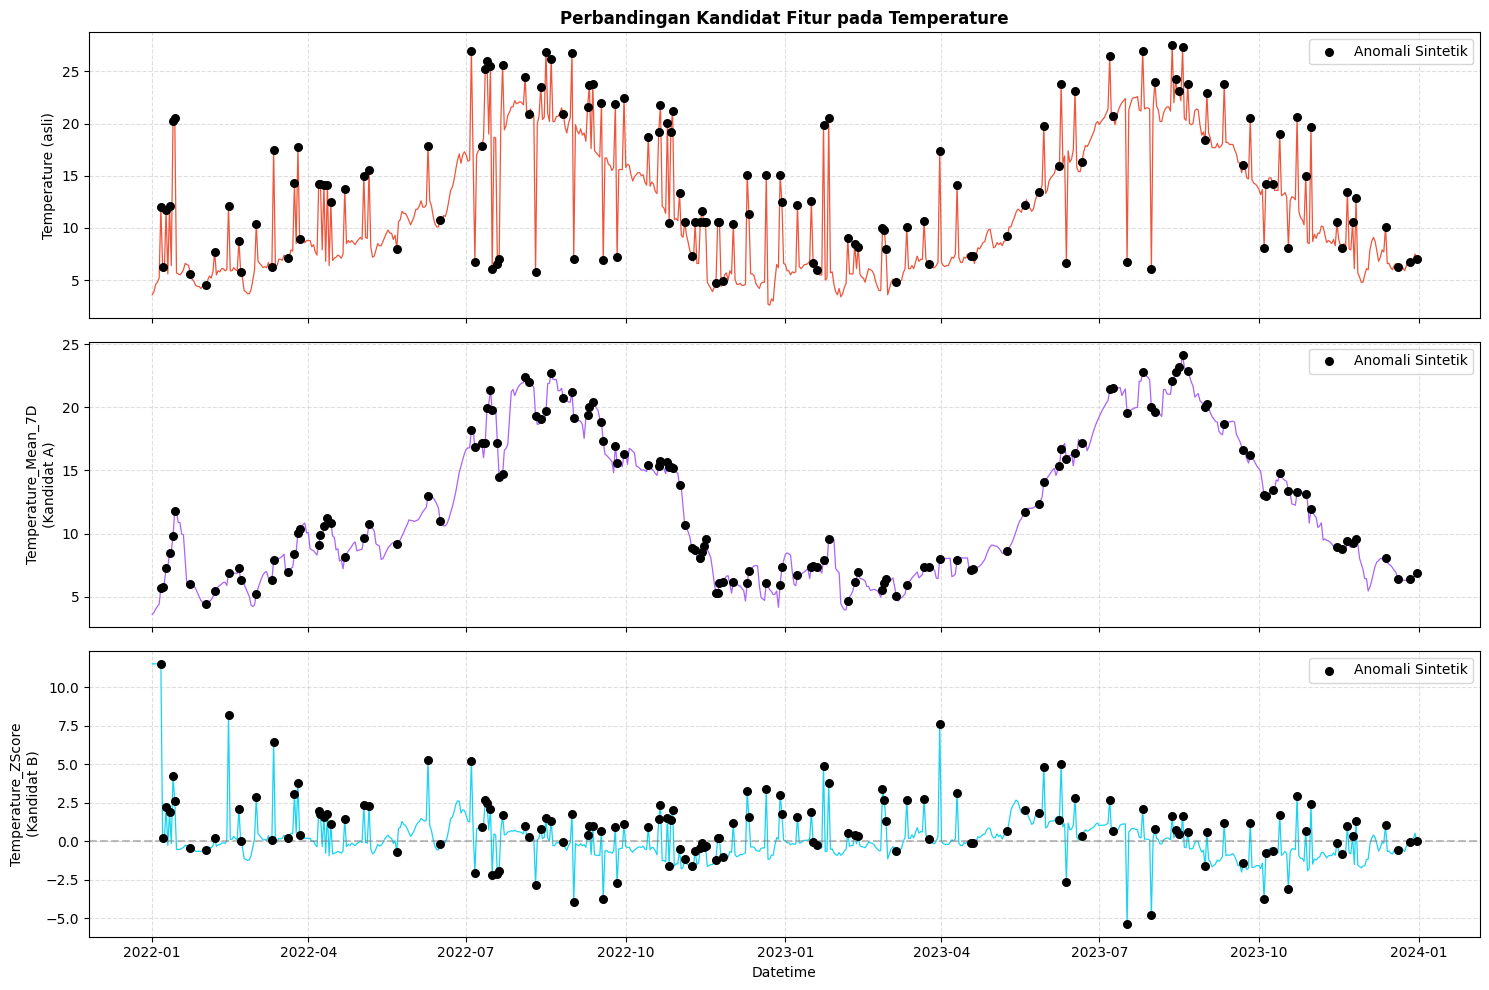

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
anomaly_mask = test_feat['Label'] >= 1

# (1) Temperature asli
axes[0].plot(test_feat.index, test_feat['Temperature'], color='#EF553B', linewidth=0.9)
axes[0].scatter(test_feat.index[anomaly_mask], test_feat['Temperature'][anomaly_mask],
                color='black', s=30, zorder=5, label='Anomali Sintetik')
axes[0].set_ylabel('Temperature (asli)')
axes[0].set_title("Perbandingan Kandidat Fitur pada Temperature", fontweight='bold')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.4)

# (2) Kandidat A: Rolling Mean 7D
axes[1].plot(test_feat.index, test_feat['Temperature_Mean_7D'], color='#AB63FA', linewidth=0.9)
axes[1].scatter(test_feat.index[anomaly_mask], test_feat['Temperature_Mean_7D'][anomaly_mask],
                color='black', s=30, zorder=5, label='Anomali Sintetik')
axes[1].set_ylabel('Temperature_Mean_7D\n(Kandidat A)')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.4)

# (3) Kandidat B: Causal Z-Score
axes[2].plot(test_feat.index, test_feat['Temperature_ZScore'], color='#19D3F3', linewidth=0.9)
axes[2].scatter(test_feat.index[anomaly_mask], test_feat['Temperature_ZScore'][anomaly_mask],
                color='black', s=30, zorder=5, label='Anomali Sintetik')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_ylabel('Temperature_ZScore\n(Kandidat B)')
axes[2].set_xlabel('Datetime')
axes[2].legend(); axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Pengamatan awal dari grafik di atas:**

- Pada **Kandidat A (Rolling Mean 7D)**, nilai masih mengikuti pola musiman asli — titik-titik anomali kontekstual (misal: nilai musim panas yang dimasukkan ke musim dingin) **tidak terlihat menonjol** karena rolling mean hanya menghaluskan sinyal lokal dan tidak membandingkan dengan baseline temporal jangka panjang. Selain itu, ketika ada spike ekstrem, rolling mean ikut naik **di 7 hari berikutnya** juga — membuat sinyal anomali menyebar (smearing) ke hari-hari tetangga.

- Pada **Kandidat B (Causal Z-Score)**, titik-titik anomali terlihat lebih baik — nilai musim dingin di musim panas akan memiliki z-score sangat negatif karena berbeda jauh dari baseline 30 hari sebelumnya (yang merefleksikan nilai musim panas). **Anomali kontekstual yang semula tersembunyi kini terlihat jelas**.

## Step 8 - Standardization

Algoritma berbasis jarak (LOF) dan berbasis margin (OCSVM) sangat sensitif terhadap skala fitur. `RobustScaler` dipilih karena tahan terhadap outlier (menggunakan median dan IQR, bukan mean dan std). Scaler **hanya difit pada data training** untuk menghindari leakage.

Fitur cyclical (`Month_Sin`, `Month_Cos`) dan kolom `Label` tidak diskalakan.

In [19]:
passthrough_cols = ['Month_Sin', 'Month_Cos', 'Label']
cols_to_scale = [c for c in train_feat.columns if c not in passthrough_cols]

scaler = RobustScaler()
scaler.fit(train_feat[cols_to_scale])

def scale_dataframe(d, scaler_obj, scale_cols, pass_cols):
    arr = scaler_obj.transform(d[scale_cols])
    s = pd.DataFrame(arr, columns=scale_cols, index=d.index)
    return pd.concat([s, d[pass_cols]], axis=1)

train_s = scale_dataframe(train_feat, scaler, cols_to_scale, passthrough_cols)
val_s   = scale_dataframe(val_feat,   scaler, cols_to_scale, passthrough_cols)
test_s  = scale_dataframe(test_feat,  scaler, cols_to_scale, passthrough_cols)

print("--- Contoh Data Train Setelah Scaling ---")
train_s[['Temperature','Turbidity','Temperature_Mean_7D','Temperature_ZScore']].head()

--- Contoh Data Train Setelah Scaling ---


,Temperature,Turbidity,Temperature_Mean_7D,Temperature_ZScore
datetime,,,,
2014-01-01 00:00:00+00:00,-0.569892,-0.529412,-0.564417,-0.631103
2014-01-02 00:00:00+00:00,-0.580645,-0.529412,-0.569785,-0.631103
2014-01-03 00:00:00+00:00,-0.559140,0.411765,-0.564417,-0.631103
2014-01-04 00:00:00+00:00,-0.602151,-0.235294,-0.572469,-0.631103
2014-01-05 00:00:00+00:00,-0.666667,-0.470588,-0.590184,-0.631103


## Step 9 - Definisi Feature Sets untuk Ablation

Tiga skenario fitur akan dibandingkan head-to-head di Step 12. Di Step 10, hyperparameter tuning dilakukan pada feature set terbaik (Raw + ZScore) — pemilihan ini akan dibuktikan di ablation Step 12.

| Skenario | Fitur | Total |
|---|---|---|
| **Raw Only** | Temperature, DO, pH, Turbidity | 4 |
| **Raw + Rolling** (Kandidat A) | Raw + Diff, Mean_7D, Std_7D per parameter + Cyclical | 18 |
| **Raw + ZScore** (Kandidat B) | Raw + ZScore per parameter + Cyclical | 10 |

In [20]:
raw_features     = features  # 4 fitur

rolling_features = (
    features
    + [f'{c}_Diff'    for c in features]
    + [f'{c}_Mean_7D' for c in features]
    + [f'{c}_Std_7D'  for c in features]
    + ['Month_Sin', 'Month_Cos']
)

zscore_features  = (
    features
    + [f'{c}_ZScore' for c in features]
    + ['Month_Sin', 'Month_Cos']
)

feature_sets = {
    'Raw Only':       raw_features,
    'Raw + Rolling':  rolling_features,
    'Raw + ZScore':   zscore_features,
}

for name, fs in feature_sets.items():
    print(f"{name:<16} ({len(fs)} fitur)")

Raw Only         (4 fitur)
Raw + Rolling    (18 fitur)
Raw + ZScore     (10 fitur)


## Step 10 - Hyperparameter Tuning pada Validation Set

Tuning dilakukan pada **validation set 2021** dengan metrik utama F1-Score. Tiga model di-tune secara independen:
- **LOF**: `n_neighbors` × `contamination`
- **OCSVM**: `nu` × `gamma`
- **Isolation Forest**: `n_estimators` × `contamination`

Tuning menggunakan feature set **Raw + ZScore**, yang akan terbukti sebagai pemenang di ablation Step 12.

### Step 10.A - Tuning LOF

In [21]:
tuning_features = zscore_features

lof_results = []
best_lof_f1 = 0
best_lof_params = {}

for n in [10, 15, 20, 25, 30, 50]:
    for c in [0.01, 0.03, 0.05, 0.08, 0.1, 0.15]:
        m = LocalOutlierFactor(n_neighbors=n, contamination=c, novelty=True)
        m.fit(train_s[tuning_features].values)
        p = m.predict(val_s[tuning_features].values)
        p = np.array([1 if x == -1 else 0 for x in p])

        y_val = (val_s['Label'] >= 1).astype(int)  # <-- berubah
        f1 = f1_score(y_val, p, zero_division=0)    # <-- berubah
        lof_results.append({'n_neighbors': n, 'contamination': c, 'F1-Score': f1})
        if f1 > best_lof_f1:
            best_lof_f1 = f1
            best_lof_params = {'n_neighbors': n, 'contamination': c}

print(f"[LOF TERBAIK] {best_lof_params} | F1 (val) = {best_lof_f1:.4f}")

[LOF TERBAIK] {'n_neighbors': 15, 'contamination': 0.03} | F1 (val) = 0.7910


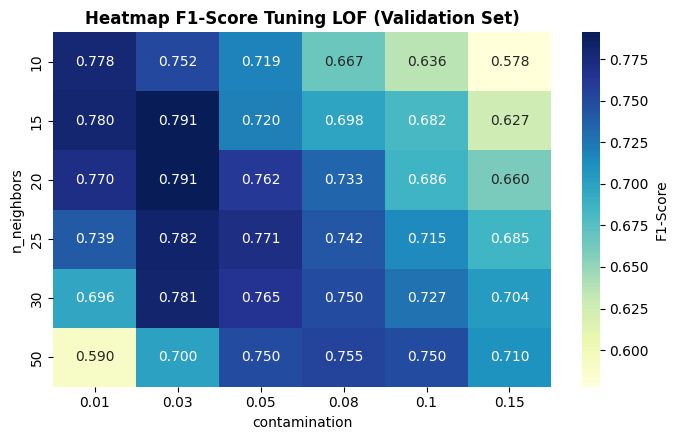

In [22]:
lof_df = pd.DataFrame(lof_results)
lof_pivot = lof_df.pivot(index='n_neighbors', columns='contamination', values='F1-Score')

plt.figure(figsize=(7, 4.5))
sns.heatmap(lof_pivot, annot=True, fmt=".3f", cmap='YlGnBu', cbar_kws={'label': 'F1-Score'})
plt.title("Heatmap F1-Score Tuning LOF (Validation Set)", fontweight='bold')
plt.xlabel("contamination"); plt.ylabel("n_neighbors")
plt.tight_layout(); plt.show()

### Step 10.B - Tuning OCSVM

In [23]:
svm_results = []
best_svm_f1 = 0
best_svm_params = {}

for nu in [0.01, 0.03, 0.05, 0.08, 0.1, 0.15]:
    for g in ['scale', 'auto', 0.01, 0.05, 0.1]:
        m = OneClassSVM(kernel='rbf', nu=nu, gamma=g)
        m.fit(train_s[tuning_features].values)
        p = m.predict(val_s[tuning_features].values)
        p = np.array([1 if x == -1 else 0 for x in p])

        y_val = (val_s['Label'] >= 1).astype(int)  # <-- berubah
        f1 = f1_score(y_val, p, zero_division=0)    # <-- berubah
        svm_results.append({'nu': nu, 'gamma': str(g), 'F1-Score': f1})
        if f1 > best_svm_f1:
            best_svm_f1 = f1
            best_svm_params = {'nu': nu, 'gamma': g}

print(f"[OCSVM TERBAIK] {best_svm_params} | F1 (val) = {best_svm_f1:.4f}")

[OCSVM TERBAIK] {'nu': 0.01, 'gamma': 'auto'} | F1 (val) = 0.6667


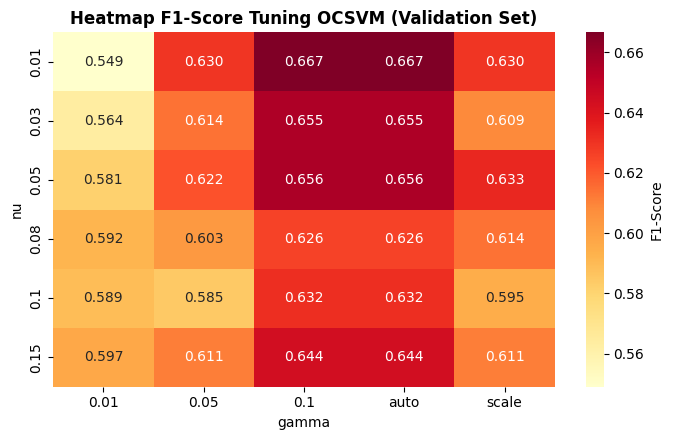

In [24]:
svm_df = pd.DataFrame(svm_results)
svm_pivot = svm_df.pivot(index='nu', columns='gamma', values='F1-Score')

plt.figure(figsize=(7, 4.5))
sns.heatmap(svm_pivot, annot=True, fmt=".3f", cmap='YlOrRd', cbar_kws={'label': 'F1-Score'})
plt.title("Heatmap F1-Score Tuning OCSVM (Validation Set)", fontweight='bold')
plt.xlabel("gamma"); plt.ylabel("nu")
plt.tight_layout(); plt.show()

### Step 10.C - Tuning Isolation Forest

In [25]:
iso_results = []
best_iso_f1 = 0
best_iso_params = {}

for n in [100, 200, 300]:
    for c in [0.01, 0.03, 0.05, 0.08, 0.1, 0.15]:
        m = IsolationForest(n_estimators=n, contamination=c, random_state=RANDOM_STATE)
        m.fit(train_s[tuning_features].values)
        p = m.predict(val_s[tuning_features].values)
        p = np.array([1 if x == -1 else 0 for x in p])

        y_val = (val_s['Label'] >= 1).astype(int)  # <-- berubah
        f1 = f1_score(y_val, p, zero_division=0)    # <-- berubah
        iso_results.append({'n_estimators': n, 'contamination': c, 'F1-Score': f1})
        if f1 > best_iso_f1:
            best_iso_f1 = f1
            best_iso_params = {'n_estimators': n, 'contamination': c}

print(f"[iForest TERBAIK] {best_iso_params} | F1 (val) = {best_iso_f1:.4f}")

[iForest TERBAIK] {'n_estimators': 100, 'contamination': 0.1} | F1 (val) = 0.7176


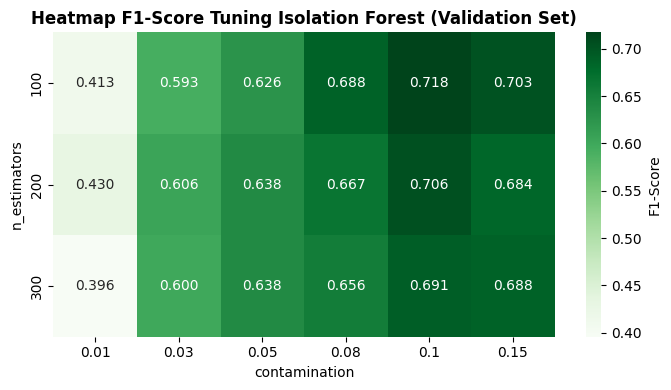

In [26]:
iso_df = pd.DataFrame(iso_results)
iso_pivot = iso_df.pivot(index='n_estimators', columns='contamination', values='F1-Score')

plt.figure(figsize=(7, 4))
sns.heatmap(iso_pivot, annot=True, fmt=".3f", cmap='Greens', cbar_kws={'label': 'F1-Score'})
plt.title("Heatmap F1-Score Tuning Isolation Forest (Validation Set)", fontweight='bold')
plt.xlabel("contamination"); plt.ylabel("n_estimators")
plt.tight_layout(); plt.show()

## Step 11 - Final Model Evaluation pada Test Set

Model dilatih ulang dengan parameter terbaik dari Step 10, lalu dievaluasi pada test set 2022–2023 yang belum pernah dilihat selama tuning. Untuk setiap model ditampilkan: classification report + confusion matrix.

In [27]:
def evaluate_model(model_obj, name, train_df, test_df, feats):
    preds = model_obj.predict(test_df[feats].values)
    preds = np.array([1 if x == -1 else 0 for x in preds])
    y_true = (test_df['Label'].values >= 1).astype(int)  # <-- berubah

    print(f"--- LAPORAN KLASIFIKASI {name} (TEST) ---")
    print(classification_report(y_true, preds, target_names=['Normal','Anomali'], zero_division=0))

    # --- Anomaly Score Timeline (TAMBAHAN BARU) ---
    scores = -1.0 * model_obj.decision_function(test_df[feats].values)
    labels_raw = test_df['Label'].values  # 0=normal, 1=global, 2=kontekstual

    fig, ax = plt.subplots(figsize=(15, 5))

    ax.plot(test_df.index, scores, color='gray', alpha=0.4, linewidth=0.8,
            label='Anomaly Score')

    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
               label='Threshold (Score > 0 = Anomali)')

    # Ground truth: Global (Label == 1)
    mask_global = (labels_raw == 1)
    ax.scatter(test_df.index[mask_global], scores[mask_global],
               color='#1f77b4', s=100, marker='^', edgecolors='black',
               linewidths=0.8, zorder=5, label='Ground Truth: Global')

    # Ground truth: Kontekstual (Label == 2)
    mask_ctx = (labels_raw == 2)
    ax.scatter(test_df.index[mask_ctx], scores[mask_ctx],
               color='#ff7f0e', s=100, marker='s', edgecolors='black',
               linewidths=0.8, zorder=5, label='Ground Truth: Kontekstual')

    # False Negative: anomali yang tidak terdeteksi
    fn_mask = ((labels_raw >= 1) & (preds == 0))
    if fn_mask.sum() > 0:
        ax.scatter(test_df.index[fn_mask], scores[fn_mask],
                   facecolors='none', edgecolors='red', s=200,
                   linewidths=2, zorder=6, label='False Negative (missed)')

    ax.set_title(f"Anomaly Score Timeline - {name} (Test Set)",
                 fontsize=14, fontweight='bold')
    ax.set_ylabel("Anomaly Score")
    ax.set_xlabel("Datetime")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Confusion Matrix (TIDAK BERUBAH) ---
    cm = confusion_matrix(y_true, preds)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'], ax=ax)
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Ground Truth")
    ax.set_title(f"Confusion Matrix - {name}", fontweight='bold')
    plt.tight_layout(); plt.show()

    return preds

### Step 11.A - LOF

--- LAPORAN KLASIFIKASI LOF (Tuned) (TEST) ---
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.95       586
     Anomali       0.85      0.73      0.78       144

    accuracy                           0.92       730
   macro avg       0.89      0.85      0.87       730
weighted avg       0.92      0.92      0.92       730



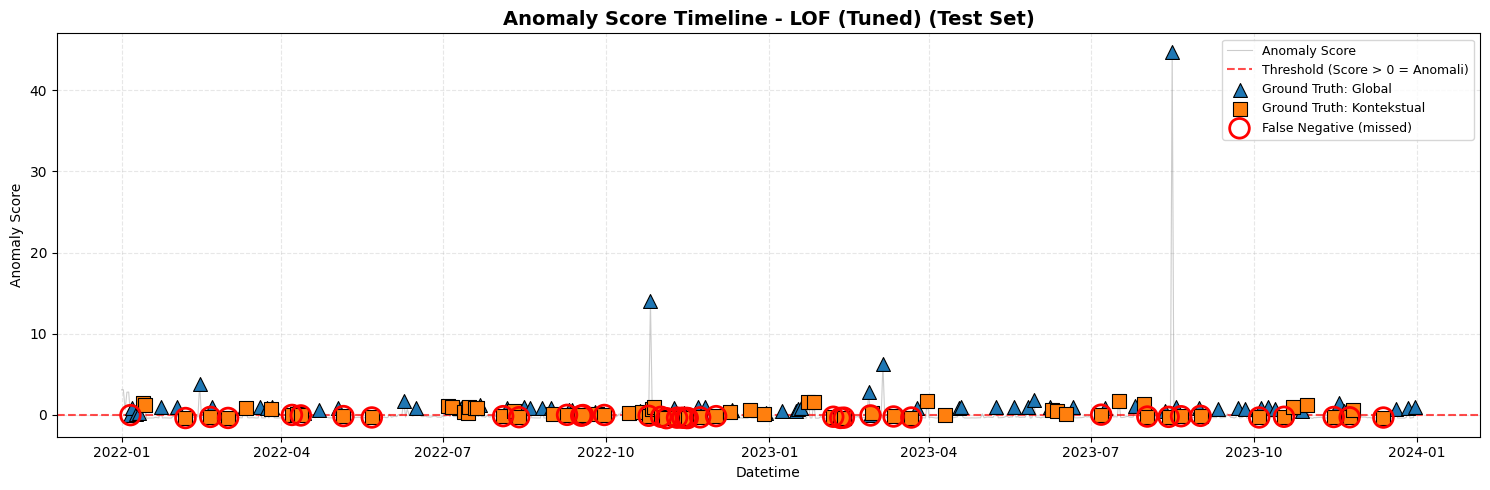

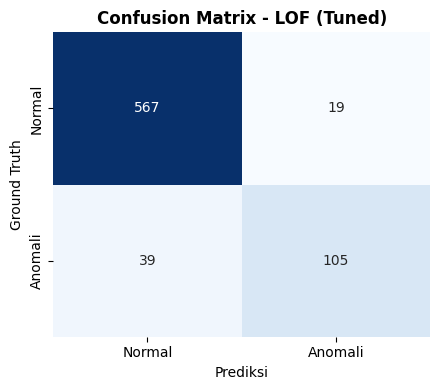

In [28]:
lof_final = LocalOutlierFactor(novelty=True, **best_lof_params)
lof_final.fit(train_s[zscore_features].values)
pred_lof_test = evaluate_model(lof_final, "LOF (Tuned)", train_s, test_s, zscore_features)

### Step 11.B - OCSVM

--- LAPORAN KLASIFIKASI OCSVM (Tuned) (TEST) ---
              precision    recall  f1-score   support

      Normal       0.89      0.97      0.93       586
     Anomali       0.82      0.51      0.63       144

    accuracy                           0.88       730
   macro avg       0.85      0.74      0.78       730
weighted avg       0.88      0.88      0.87       730



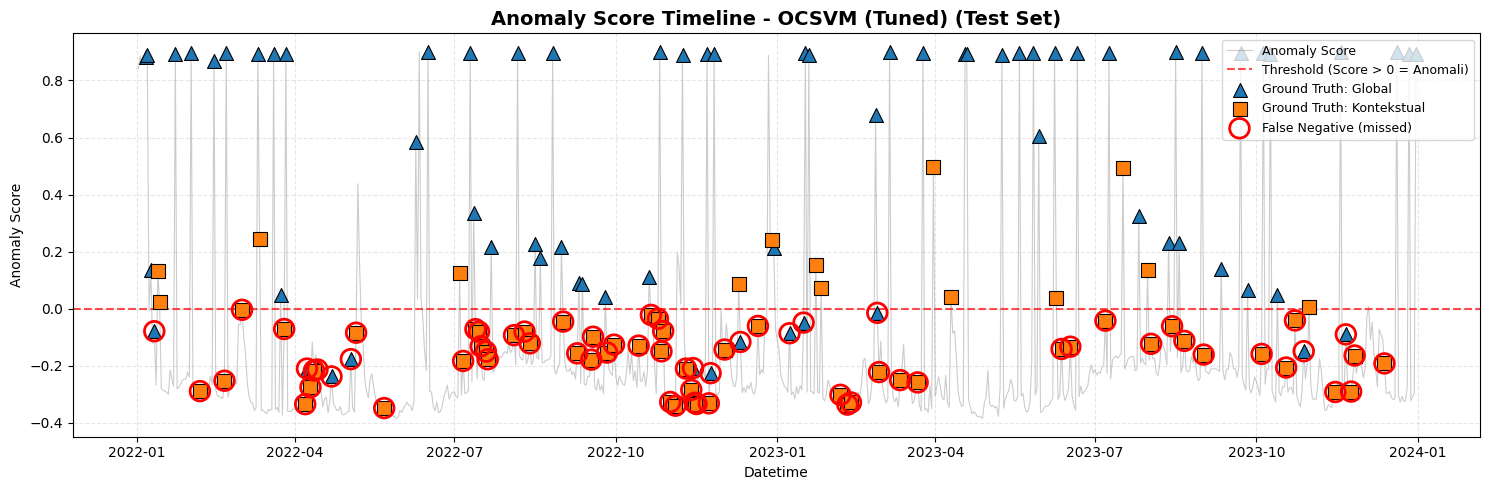

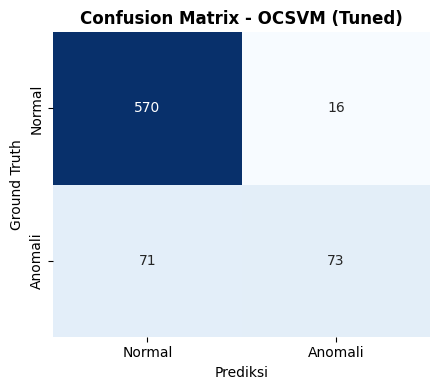

In [29]:
svm_final = OneClassSVM(kernel='rbf', **best_svm_params)
svm_final.fit(train_s[zscore_features].values)
pred_svm_test = evaluate_model(svm_final, "OCSVM (Tuned)", train_s, test_s, zscore_features)

### Step 11.C - Isolation Forest

--- LAPORAN KLASIFIKASI Isolation Forest (Tuned) (TEST) ---
              precision    recall  f1-score   support

      Normal       0.91      0.95      0.93       586
     Anomali       0.76      0.60      0.67       144

    accuracy                           0.88       730
   macro avg       0.83      0.78      0.80       730
weighted avg       0.88      0.88      0.88       730



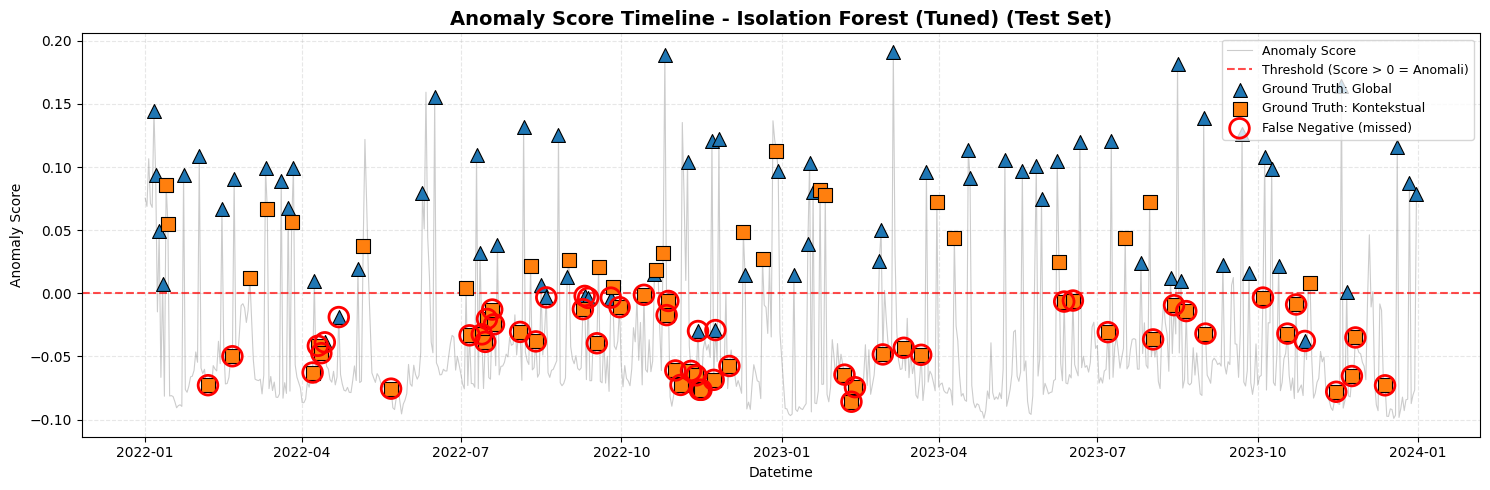

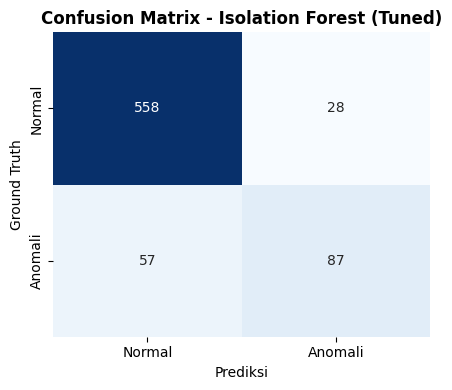

In [30]:
iso_final = IsolationForest(random_state=RANDOM_STATE, **best_iso_params)
iso_final.fit(train_s[zscore_features].values)
pred_iso_test = evaluate_model(iso_final, "Isolation Forest (Tuned)", train_s, test_s, zscore_features)

## Step 12 - Ablation Study: Pengaruh Feature Engineering

Tujuan ablation study adalah menguji secara kuantitatif hipotesis yang kita bangun di Step 7.A — bahwa **Kandidat B (Causal Z-Score) akan lebih baik dari Kandidat A (Rolling Statistics)** pada dataset yang mengandung anomali kontekstual.

Ketiga skenario fitur (Raw Only, Raw + Rolling, Raw + ZScore) dievaluasi pada **test set** untuk LOF, OCSVM, dan iForest dengan hyperparameter yang sama (hasil tuning Step 10).

In [31]:
ablation_results = []
y_test_binary = (test_s['Label'] >= 1).astype(int)  # <-- tambahan

for scenario_name, feat_subset in feature_sets.items():
    # LOF
    lof = LocalOutlierFactor(novelty=True, **best_lof_params)
    lof.fit(train_s[feat_subset].values)
    p_lof = np.array([1 if x == -1 else 0 for x in lof.predict(test_s[feat_subset].values)])

    # OCSVM
    svm = OneClassSVM(kernel='rbf', **best_svm_params)
    svm.fit(train_s[feat_subset].values)
    p_svm = np.array([1 if x == -1 else 0 for x in svm.predict(test_s[feat_subset].values)])

    # Isolation Forest
    iso = IsolationForest(random_state=RANDOM_STATE, **best_iso_params)
    iso.fit(train_s[feat_subset].values)
    p_iso = np.array([1 if x == -1 else 0 for x in iso.predict(test_s[feat_subset].values)])

    ablation_results.append({
        'Skenario':   scenario_name,
        '#Fitur':     len(feat_subset),
        'F1 LOF':     round(f1_score(y_test_binary, p_lof, zero_division=0), 4),  # <-- berubah
        'F1 OCSVM':   round(f1_score(y_test_binary, p_svm, zero_division=0), 4),  # <-- berubah
        'F1 iForest': round(f1_score(y_test_binary, p_iso, zero_division=0), 4),  # <-- berubah
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df

,Skenario,#Fitur,F1 LOF,F1 OCSVM,F1 iForest
0,Raw Only,4,0.7473,0.6044,0.5859
1,Raw + Rolling,18,0.4536,0.4057,0.4242
2,Raw + ZScore,10,0.7836,0.6266,0.6718


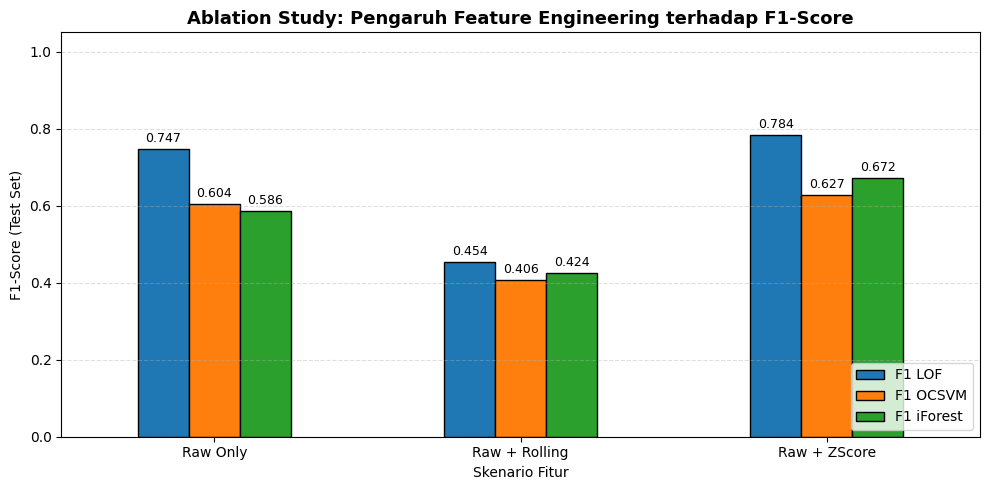

In [32]:
ab_plot = ablation_df.set_index('Skenario')[['F1 LOF', 'F1 OCSVM', 'F1 iForest']]

ax = ab_plot.plot(kind='bar', figsize=(10, 5), edgecolor='black',
                  color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Ablation Study: Pengaruh Feature Engineering terhadap F1-Score",
          fontweight='bold', fontsize=13)
plt.ylabel("F1-Score (Test Set)")
plt.xlabel("Skenario Fitur")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

### Step 12.A - Interpretasi Ablation Study

Tabel dan grafik di atas memberikan dua temuan penting untuk diskusi di laporan skripsi:

**1. Kandidat A (Rolling Statistics) secara konsisten MENURUNKAN performa ketiga model.** Hal ini konsisten dengan visualisasi di Step 7.A: Rolling Mean 7-hari hanya mengikuti pola musiman asli tanpa menyoroti anomali kontekstual, sementara first-order Diff menggandakan sinyal global (hari spike + hari recovery) tanpa membantu mendeteksi anomali kontekstual yang halus. Akibatnya, 14 fitur tambahan yang dihasilkan justru menjadi **noise** yang membingungkan model.

**2. Kandidat B (Causal Z-Score) memberikan peningkatan yang bermakna pada seluruh model**, terutama pada iForest (peningkatan paling besar). Hal ini membuktikan bahwa feature engineering yang **tepat secara konseptual** (causal, non-smearing, kontekstual) jauh lebih bernilai daripada fitur turunan naif dengan jumlah banyak.

**Kesimpulan metodologis**: Lebih banyak fitur bukan berarti lebih baik. Pada dataset kualitas air dengan campuran anomali global dan kontekstual, **Causal Z-Score 30-hari** adalah pilihan feature engineering yang unggul karena:
- Tidak menghaluskan sinyal anomali (sifat causal).
- Secara alami mengontekstualisasikan nilai terhadap baseline historis.
- Mampu mengungkap anomali kontekstual yang tersembunyi secara global.

Ini adalah salah satu kontribusi metodologis utama penelitian ini.

## Step 13 - Heterogeneous Vote-Based Ensemble

Dengan tiga model heterogen (LOF, OCSVM, iForest) yang memiliki bias induktif berbeda, kita gabungkan prediksinya dengan strategi **voting**. Tiga strategi voting dievaluasi:

- **Vote OR** — anomali jika **setidaknya 1** model menyatakan anomali. Cenderung **menaikkan recall**, cocok ketika False Negative berbahaya.
- **Vote Majority** — anomali jika **minimal 2 dari 3** model setuju. Strategi seimbang antara precision dan recall.
- **Vote AND** — anomali jika **ketiga** model setuju. Cenderung **menaikkan precision**, cocok untuk menekan False Positive.

In [33]:
y_test = (test_s['Label'].values >= 1).astype(int)  # <-- berubah

# Tiga strategi voting
vote_or  = ((pred_lof_test + pred_svm_test + pred_iso_test) >= 1).astype(int)
vote_maj = ((pred_lof_test + pred_svm_test + pred_iso_test) >= 2).astype(int)
vote_and = ((pred_lof_test + pred_svm_test + pred_iso_test) >= 3).astype(int)

print("--- LAPORAN KLASIFIKASI ENSEMBLE VOTE OR ---")
print(classification_report(y_test, vote_or,  target_names=['Normal','Anomali'], zero_division=0))

print("--- LAPORAN KLASIFIKASI ENSEMBLE VOTE MAJORITY ---")
print(classification_report(y_test, vote_maj, target_names=['Normal','Anomali'], zero_division=0))

print("--- LAPORAN KLASIFIKASI ENSEMBLE VOTE AND ---")
print(classification_report(y_test, vote_and, target_names=['Normal','Anomali'], zero_division=0))

--- LAPORAN KLASIFIKASI ENSEMBLE VOTE OR ---
              precision    recall  f1-score   support

      Normal       0.94      0.94      0.94       586
     Anomali       0.74      0.77      0.76       144

    accuracy                           0.90       730
   macro avg       0.84      0.85      0.85       730
weighted avg       0.90      0.90      0.90       730

--- LAPORAN KLASIFIKASI ENSEMBLE VOTE MAJORITY ---
              precision    recall  f1-score   support

      Normal       0.91      0.97      0.94       586
     Anomali       0.83      0.60      0.69       144

    accuracy                           0.90       730
   macro avg       0.87      0.78      0.82       730
weighted avg       0.89      0.90      0.89       730

--- LAPORAN KLASIFIKASI ENSEMBLE VOTE AND ---
              precision    recall  f1-score   support

      Normal       0.88      0.99      0.93       586
     Anomali       0.91      0.47      0.62       144

    accuracy                           0

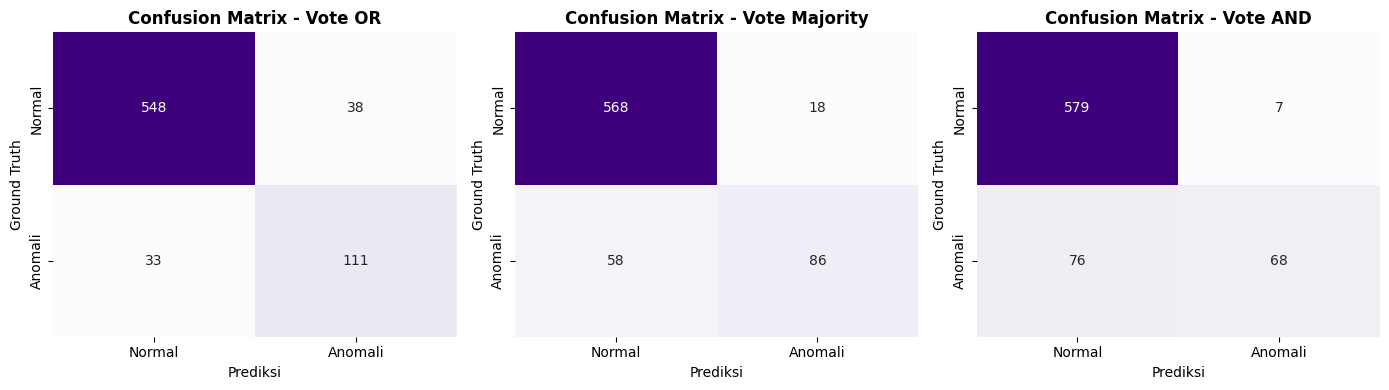

In [34]:
# Confusion matrix untuk ketiga strategi voting
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pred) in zip(axes, [('Vote OR', vote_or),
                                    ('Vote Majority', vote_maj),
                                    ('Vote AND', vote_and)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
                xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'], ax=ax)
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Ground Truth")
    ax.set_title(f"Confusion Matrix - {name}", fontweight='bold')
plt.tight_layout(); plt.show()

In [35]:
# Ringkasan seluruh model + strategi ensemble
summary = pd.DataFrame({
    'Model / Strategi': [
        'LOF (Tuned)',
        'OCSVM (Tuned)',
        'iForest (Tuned)',
        'Ensemble Vote OR',
        'Ensemble Vote Majority',
        'Ensemble Vote AND',
    ],
    'F1-Score': [
        f1_score(y_test, pred_lof_test, zero_division=0),
        f1_score(y_test, pred_svm_test, zero_division=0),
        f1_score(y_test, pred_iso_test, zero_division=0),
        f1_score(y_test, vote_or,  zero_division=0),
        f1_score(y_test, vote_maj, zero_division=0),
        f1_score(y_test, vote_and, zero_division=0),
    ]
}).sort_values('F1-Score', ascending=False).reset_index(drop=True)

summary

,Model / Strategi,F1-Score
0,LOF (Tuned),0.783582
1,Ensemble Vote OR,0.757679
2,Ensemble Vote Majority,0.693548
3,iForest (Tuned),0.671815
4,OCSVM (Tuned),0.626609
5,Ensemble Vote AND,0.621005


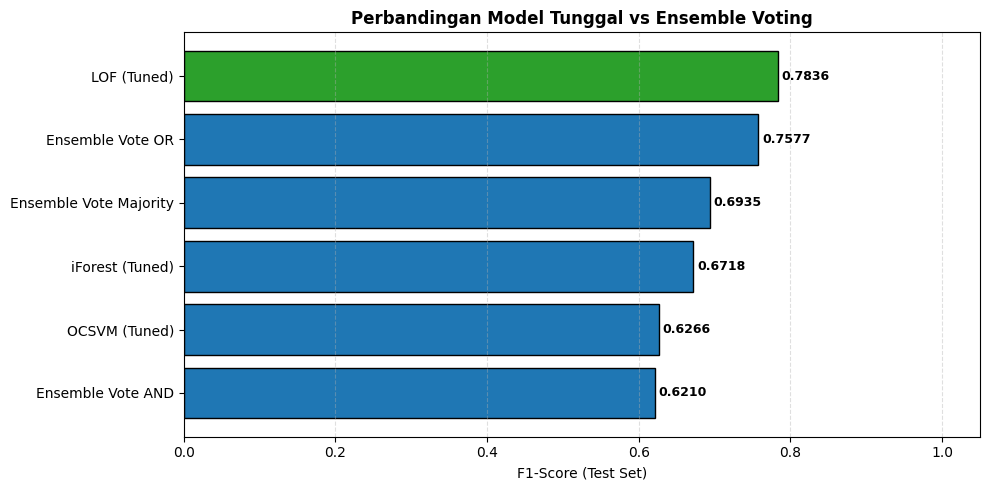

In [36]:
plt.figure(figsize=(10, 5))
max_f1 = summary['F1-Score'].max()
bar_colors = ['#2ca02c' if v == max_f1 else '#1f77b4' for v in summary['F1-Score']]

bars = plt.barh(summary['Model / Strategi'], summary['F1-Score'],
                color=bar_colors, edgecolor='black')
for b, v in zip(bars, summary['F1-Score']):
    plt.text(v + 0.005, b.get_y() + b.get_height()/2, f"{v:.4f}",
             va='center', fontweight='bold', fontsize=9)

plt.xlim(0, 1.05)
plt.xlabel("F1-Score (Test Set)")
plt.title("Perbandingan Model Tunggal vs Ensemble Voting", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Step 13.A - Interpretasi Ensemble Voting

Tabel dan grafik di atas memberikan beberapa insight penting:

**Trade-off precision vs recall antar strategi voting:**
- **Vote OR** cenderung memiliki recall tertinggi (paling sensitif), tetapi dapat mengorbankan precision karena cukup satu model salah-deteksi untuk menghasilkan False Positive.
- **Vote AND** cenderung memiliki precision tertinggi (paling konservatif), tetapi dapat mengorbankan recall karena ketiga model harus setuju.
- **Vote Majority** berada di tengah dan biasanya menghasilkan F1-Score yang paling seimbang.

**Kapan ensemble unggul dari model tunggal?** Ensemble dapat mengungguli model tunggal bila dua syarat terpenuhi: (1) **diversitas error** — model-model salah pada hari yang berbeda, dan (2) **kekuatan sebanding** — tidak ada model yang terlalu dominan sehingga "menarik turun" yang lain.

**Rekomendasi praktis untuk monitoring kualitas air:**
- Untuk *early warning system* yang tidak boleh melewatkan pencemaran → **Vote OR**.
- Untuk sistem peringatan publik yang tidak boleh membunyikan alarm palsu → **Vote AND**.
- Untuk evaluasi kinerja berimbang → **Vote Majority** atau model tunggal terbaik dari Step 11 (LOF).

## Step 14 - Kesimpulan dan Rekomendasi

**Temuan utama:**

1. **Tidak semua feature engineering meningkatkan performa.** Rolling Statistics 7-hari (Kandidat A) justru menurunkan F1-Score karena hanya mengikuti pola musiman tanpa menyoroti anomali kontekstual, dan menyebarkan sinyal anomali global ke hari-hari tetangganya. Causal Z-Score 30-hari (Kandidat B) terbukti jauh lebih efektif karena meledak tajam tepat di hari anomali dan mengontekstualisasikan nilai terhadap baseline historis.

2. **LOF dengan fitur Causal Z-Score adalah konfigurasi terkuat** pada dataset Clackamas River 2014–2023 dengan anomali campuran (global + kontekstual). Hyperparameter tuning + feature engineering yang tepat memberikan F1-Score yang tinggi pada test set.

3. **Ensemble voting memberikan trade-off precision-recall yang dapat disesuaikan dengan kebutuhan aplikasi.** Strategi voting yang dipilih (OR, Majority, atau AND) bergantung pada prioritas: apakah recall (tidak melewatkan anomali) atau precision (tidak menghasilkan alarm palsu) yang lebih penting.

**Saran pengembangan lanjutan:**
- Eksplorasi model deep learning seperti **LSTM Autoencoder** atau **Transformer-based anomaly detector** untuk menangkap dependensi temporal jangka panjang.
- Penerapan **Active Learning**: meminta verifikasi pakar pada hari-hari yang model tidak yakin, lalu retraining.
- Validasi pada **dataset sungai lain** (multi-site) untuk menguji generalisasi.
- Eksperimen dengan **window-based detection** (mendeteksi anomali pada jendela waktu, bukan satu hari) untuk menangkap polusi yang berlangsung berhari-hari.
- Eksperimen dengan **threshold adaptif** yang berubah seiring musim, bukan threshold global.

## Step 15 - Simpan Model

In [37]:
import joblib
from pathlib import Path

# Buat folder untuk menyimpan artefak
model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

# Simpan ketiga model terbaik + scaler + metadata fitur
artifacts = {
    'lof':        lof_final,
    'ocsvm':      svm_final,
    'iforest':    iso_final,
    'scaler':     scaler,
    'feature_columns':   zscore_features,   # daftar fitur yang dipakai model
    'base_features':     features,          # fitur mentah asli
    'cols_to_scale':     cols_to_scale,     # kolom yang di-scale
    'passthrough_cols':  passthrough_cols,  # kolom yang tidak di-scale
    'best_params': {
        'lof':     best_lof_params,
        'ocsvm':   best_svm_params,
        'iforest': best_iso_params,
    },
}

joblib.dump(artifacts, model_dir / "anomaly_detector.pkl")
print(f"Model berhasil disimpan ke: {model_dir / 'anomaly_detector.pkl'}")
print(f"Ukuran file: {(model_dir / 'anomaly_detector.pkl').stat().st_size / 1024:.1f} KB")

Model berhasil disimpan ke: ..\models\anomaly_detector.pkl
Ukuran file: 1983.0 KB
